Detecting and removing inactive segments at the beginning and end of each file from UiS4ADL.

In [1]:
import os
import random
import warnings
import json
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# Suppress warnings from Python and external libraries
os.environ["PYTHONWARNINGS"] = "ignore"
warnings.filterwarnings("ignore")

In [2]:
fs = 100 #  frequency in Hz

path = f"../Data/UiS4ADL/Processed/UiS4ADL_100hz_inactivity_removed.csv"
df = pd.read_csv(path)

In [3]:
df

,timestamp,accX[mg],accY[mg],accZ[mg],gyroX[mdps],gyroY[mdps],gyroZ[mdps],magnX[mG],magnY[mG],magnZ[mG],...,fxGravityY[g],fxGravityZ[g],fxLinAccX[g],fxLinAccY[g],fxLinAccZ[g],fxHeading[deg],adl,session,subject,fileID
0,0.0,-29.0,-587.0,823.0,-1820.0,-1400.0,1820.0,141.0,219.0,-523.0,...,-0.035,-0.819,-0.014,-0.006,0.004,32.815,1,1,0,70
1,10.0,-26.0,-556.0,833.0,-840.0,-1260.0,2520.0,141.0,219.0,-523.0,...,-0.035,-0.819,0.017,-0.009,0.014,32.784,1,1,0,70
2,20.0,-32.0,-536.0,844.0,-840.0,-1120.0,2450.0,136.0,219.0,-511.0,...,-0.035,-0.819,0.037,-0.003,0.025,32.753,1,1,0,70
3,30.0,-32.0,-535.0,856.0,-2590.0,-350.0,1890.0,136.0,207.0,-516.0,...,-0.035,-0.823,0.032,-0.003,0.033,32.748,1,1,0,70
4,40.0,-29.0,-573.0,832.0,-4130.0,490.0,1470.0,147.0,217.0,-517.0,...,-0.035,-0.823,-0.006,-0.006,0.009,32.728,1,1,0,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9715648,27730.0,836.0,-412.0,47.0,10640.0,10570.0,2590.0,-14.0,-103.0,-87.0,...,0.886,-0.093,0.043,0.050,-0.046,257.834,9,5,3245,4947
9715649,27740.0,827.0,-412.0,47.0,11760.0,10080.0,1610.0,-14.0,-103.0,-87.0,...,0.885,-0.096,0.043,0.058,-0.049,257.704,9,5,3245,4947
9715650,27750.0,816.0,-409.0,45.0,12740.0,9520.0,560.0,-12.0,-106.0,-84.0,...,0.885,-0.099,0.046,0.069,-0.054,257.563,9,5,3245,4947
9715651,27760.0,809.0,-410.0,42.0,13580.0,8820.0,-560.0,-17.0,-96.0,-84.0,...,0.886,-0.095,0.044,0.077,-0.053,257.724,9,5,3245,4947


In [4]:
# Parameters for segmenting the data into windows
seconds = 0.5
window_size = int(fs * seconds)

In [5]:
df.columns

Index(['timestamp', 'accX[mg]', 'accY[mg]', 'accZ[mg]', 'gyroX[mdps]',
       'gyroY[mdps]', 'gyroZ[mdps]', 'magnX[mG]', 'magnY[mG]', 'magnZ[mG]',
       'fxQ1', 'fxQ2', 'fxQ3', 'fxQ4', 'fxYaw[deg]', 'fxPitch[deg]',
       'fxRoll[deg]', 'fxGravityX[g]', 'fxGravityY[g]', 'fxGravityZ[g]',
       'fxLinAccX[g]', 'fxLinAccY[g]', 'fxLinAccZ[g]', 'fxHeading[deg]', 'adl',
       'session', 'subject', 'fileID'],
      dtype='object')

In [6]:
with open('../Data/adl_dict.json', 'r') as f:
    adl_dict = json.load(f) # load the adl dictionary
    
adl_dict

{'1': 'drink water',
 '2': 'eat meal',
 '3': 'open a bottle',
 '4': 'open a box',
 '5': 'brush teeth',
 '6': 'brush hair',
 '7': 'take off jacket',
 '8': 'put on jacket',
 '9': 'put on shoe',
 '10': 'take off shoe',
 '11': 'put on glasses',
 '12': 'take off glasses',
 '13': 'sit down',
 '14': 'stand up',
 '15': 'writing',
 '16': 'phone call',
 '17': 'type on keyboard',
 '18': 'salute (wave hand)',
 '19': 'sneeze cough',
 '20': 'blow nose',
 '21': 'washing hands',
 '22': 'dusting',
 '23': 'ironing',
 '24': 'washing dishes'}

## Accelerometer Data Selection for Activity Recognition

In [ ]:
# Test the improved approach on a random fileID
random_file_id = random.choice(df['fileID'].unique()) # 426 was used as an example in the thesis
print(f"Randomly selected fileID: {random_file_id}")

# Subset the dataframe to only include one file
file_id = random_file_id
selected_file_df = df[(df['fileID'] == file_id)].copy()

Randomly selected fileID: 426


In [ ]:
def apply_filter(df):
    """
    Apply a filter to the accelerometer data to detect rapid changes in motion.
    """
    filtered_df = df.copy()
    
    # Define a kernel
    kernel = np.array([1, -4, 6, -4, 1])
    
    for axis in ['accX[mg]', 'accY[mg]', 'accZ[mg]']:
        signal = df[axis].values
        pad_width = len(kernel) // 2
        
        # Pad signal with edge values to handle boundaries
        padded_signal = np.pad(signal, pad_width, mode='edge')  
        
        # Apply convolution
        filtered = np.convolve(padded_signal, kernel, mode='valid')
        
        filtered_df[f'filtered_{axis}'] = filtered
    return filtered_df

def detect_activity_periods_laplacian(df, fs, window_size_sec=0.05, min_active_windows=5):
    """
    Detect periods of activity in accelerometer data using a finite-difference filter
    and adaptive thresholding.
    """
    filtered_df = apply_filter(df)
    
    # Calculate activity metric for each axis
    activity_metric = np.zeros(len(df))
    
    activity_metric = np.linalg.norm(filtered_df[['filtered_accX[mg]', 'filtered_accY[mg]', 'filtered_accZ[mg]']], axis=1)
    
    window_size = int(window_size_sec * fs)
    
    # Calculate activity metrics for each window
    activity_scores = []
    timestamps = []
    
    for i in range(0, len(activity_metric) - window_size, window_size//2):  # 50% overlap
        window = activity_metric[i:i+window_size]
        
        activity_score = np.mean(window) + 2*np.std(window) + 0.5*np.max(window)
        activity_scores.append(activity_score)
        timestamps.append(i)
    
    activity_scores = np.array(activity_scores)
    
    # Add threshold for distinguishing active periods from the inactive ones
    threshold = np.percentile(activity_scores, 70)
    is_active = activity_scores > threshold
    
    # Define minimum window requirement
    active_periods = []
    current_streak = 0
    streak_start = 0
    
    for i, active in enumerate(is_active):
        if active:
            if current_streak == 0:
                streak_start = i
            current_streak += 1
        else:
            if current_streak >= min_active_windows:
                active_periods.append((streak_start, i - 1))
            current_streak = 0
    
    if current_streak >= min_active_windows:
        active_periods.append((streak_start, len(is_active) - 1))
    
    # If no activity found, return full range (to avoid losing data in case thresholding is too aggressive)
    if not active_periods:
        return 0, len(df) - 1, filtered_df
    
    # Find first and last active periods (ignore any in the middle)
    start_window = active_periods[0][0]
    end_window = active_periods[-1][1]
    
    # Convert window indices to sample indices
    start_idx = max(0, timestamps[start_window])
    end_idx = min(len(df) - 1, timestamps[min(end_window, len(timestamps)-1)] + window_size)
    
    # Require minimum active segment length (at least 1 second)
    min_segment_length = fs * 1  # 1 second
    if end_idx - start_idx < min_segment_length:
        # If segment is too short, revert to using the full range
        return 0, len(df) - 1, filtered_df
    
    return start_idx, end_idx, filtered_df

In [9]:
def visualize_activity_detection_by_axis(df, filtered_df, start_idx, end_idx):
    """
    Visualize raw and filtered data for each accelerometer axis in separate plots.
    """
    # Get metadata for the title
    adl_code = int(df['adl'].iloc[0])
    adl_name = adl_dict[str(adl_code)]
    subject = df['subject'].iloc[0]
    session = df['session'].iloc[0]
    
    # Create timestamp in seconds for x-axis
    time_sec = df['timestamp'] / 1000  # Assuming timestamp is in milliseconds
    time_normalized = time_sec - time_sec.iloc[0]  # Start at 0
    
    # Create figure with 3 subplots (one for each axis)
    fig, axs = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
    
    # # Main title for the figure
    # fig.suptitle(f"Analysis for fileID {file_id} (adl {adl_code}: {adl_name}, subject: {subject}, session: {session})", 
    #             fontsize=14) # fontweight='bold')
    
    axis_labels = ['X', 'Y', 'Z']
    
    for i, axis in enumerate(['accX[mg]', 'accY[mg]', 'accZ[mg]']):
        ax = axs[i]
        
        # Plot raw data
        ax.plot(time_normalized, df[axis], label=f'Input {axis_labels[i]}', color='blue', alpha=0.7)
        
        # Plot filtered data
        ax.plot(time_normalized, filtered_df[f'filtered_{axis}'], label=f'Filtered {axis_labels[i]}', 
                color='red', alpha=0.7, linestyle='--')
        
        # Add background colors for active/inactive periods
        if start_idx > 0:
            ax.axvspan(time_normalized.iloc[0], time_normalized.iloc[start_idx], 
                      color='red', alpha=0.2, label='Inactive')
        
        ax.axvspan(time_normalized.iloc[start_idx], time_normalized.iloc[end_idx], 
                  color='green', alpha=0.2, label='Active')
        
        if end_idx < len(df) - 1:
            ax.axvspan(time_normalized.iloc[end_idx], time_normalized.iloc[-1], 
                      color='red', alpha=0.2)
        
        ax.set_title(f'Accelerometer {axis_labels[i]}-axis')
        ax.set_ylabel(f'{axis}')
        ax.legend(loc='upper right')
        ax.grid(True)
    
    # Set common x-axis label
    axs[2].set_xlabel('Time [s]')
    
    plt.tight_layout(rect=[0, 0, 1, 0.97])  # Adjust layout to make room for the title
    plt.show()
    
    total_duration = time_normalized.iloc[-1] - time_normalized.iloc[0]
    active_duration = time_normalized.iloc[end_idx] - time_normalized.iloc[start_idx]
    inactive_start = time_normalized.iloc[start_idx] - time_normalized.iloc[0] if start_idx > 0 else 0
    inactive_end = time_normalized.iloc[-1] - time_normalized.iloc[end_idx] if end_idx < len(df) - 1 else 0
    
    print(f"Activity Detection Results:")
    print(f"Total recording duration: {total_duration:.2f} seconds")
    print(f"Active period: {active_duration:.2f} seconds ({active_duration/total_duration*100:.1f}%)")
    print(f"Inactive period at start: {inactive_start:.2f} seconds")
    print(f"Inactive period at end: {inactive_end:.2f} seconds")
    
    return df.iloc[start_idx:end_idx+1]  # Return original data from active period

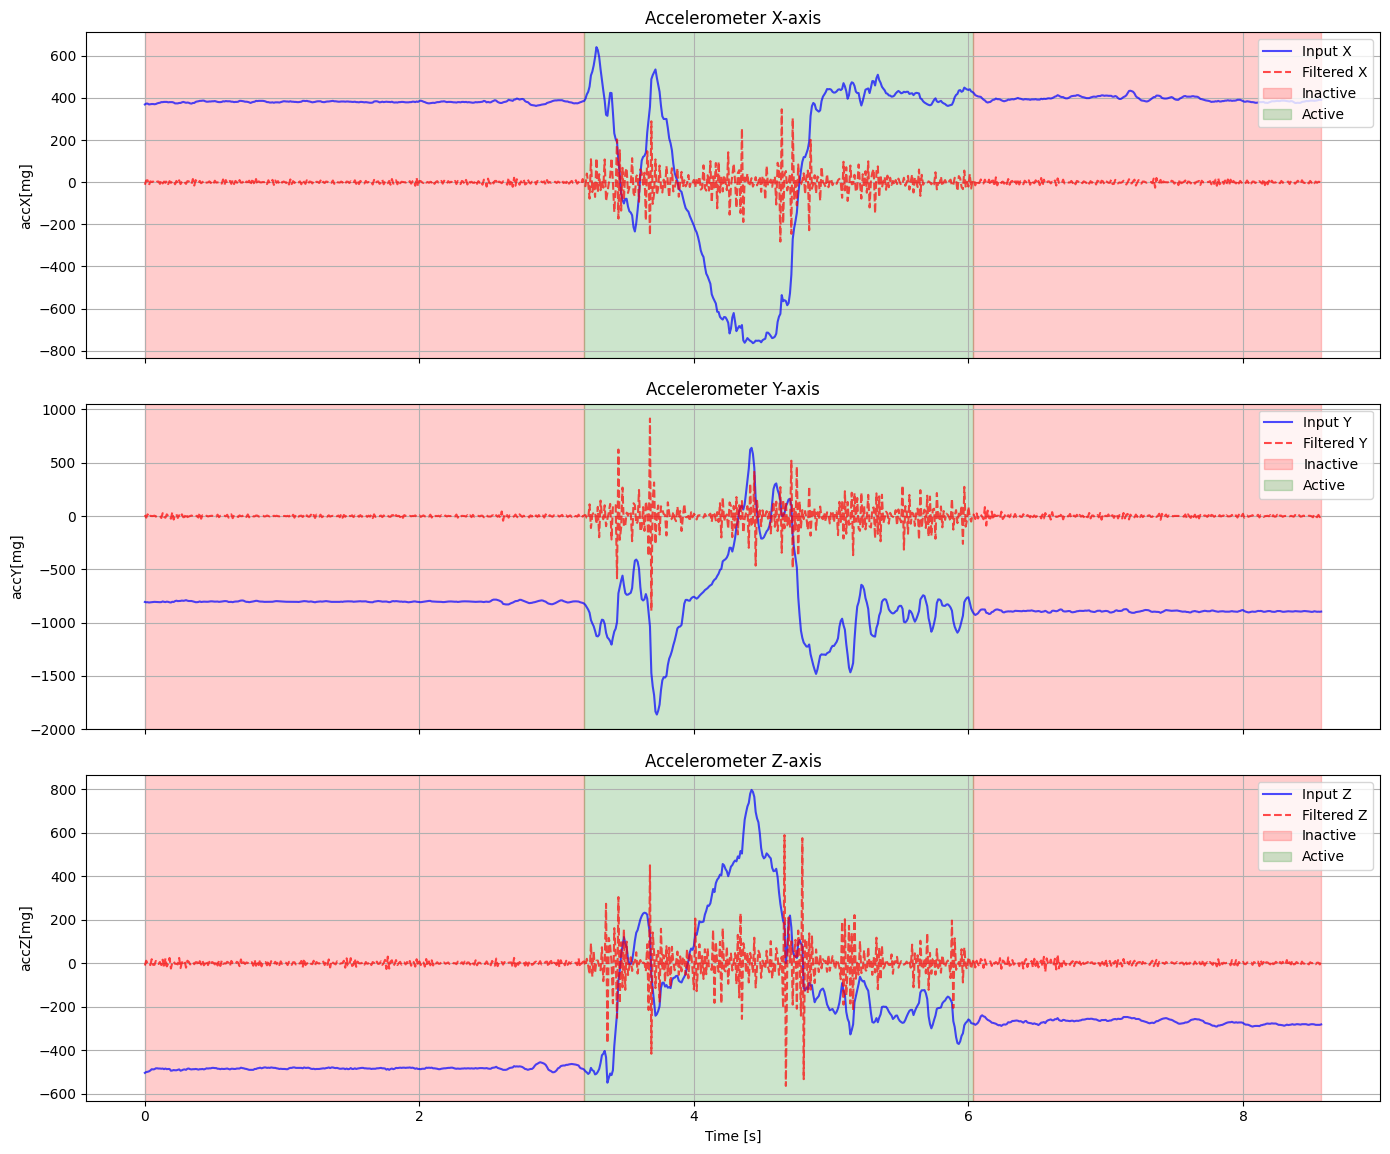

Activity Detection Results:
Total recording duration: 8.57 seconds
Active period: 2.83 seconds (33.0%)
Inactive period at start: 3.20 seconds
Inactive period at end: 2.54 seconds

Original length: 858 segments
Trimmed length: 284 segments
Removed 574 segments (66.9%)


In [10]:
# Detect activity periods
start_idx, end_idx, filtered_df = detect_activity_periods_laplacian(selected_file_df, fs, min_active_windows=5)

trimmed_df = visualize_activity_detection_by_axis(selected_file_df, filtered_df, start_idx, end_idx)

print(f"\nOriginal length: {len(selected_file_df)} segments")
print(f"Trimmed length: {len(trimmed_df)} segments")
print(f"Removed {len(selected_file_df) - len(trimmed_df)} segments ({(len(selected_file_df) - len(trimmed_df))/len(selected_file_df)*100:.1f}%)")

The results show that the procedure detects periods of inactivity quite adequately.

## Run the analysis on the entire dataframe

In [11]:
def process_all_files(df, fs):
    """
    Process all fileIDs in the dataset, detect activity periods, and return a new dataframe with inactive periods removed.
    """
    file_ids = df['fileID'].unique()
    
    processed_data = []
    log_data = []
    
    # Create a dictionary to store statistics for each file
    stats = {
        'fileID': [],
        'adl': [],
        'subject': [],
        'session': [],
        'original_duration': [],
        'trimmed_duration': [],
        'percent_removed': []
    }
    
    # Process each fileID
    total_files = len(file_ids)
    for i, file_id in enumerate(file_ids):
        file_df = df[df['fileID'] == file_id].copy()
        
        # Get metadata
        adl_code = int(file_df['adl'].iloc[0])
        adl_name = adl_dict.get(str(adl_code), 'unknown')
        subject = file_df['subject'].iloc[0]
        session = file_df['session'].iloc[0]
        
        # Only print progress every 10% of files
        if i % max(1, total_files // 10) == 0:
            print(f"Processing files: {i}/{total_files} ({i/total_files*100:.1f}%)")
        
        log_entry = {
            'fileID': file_id,
            'adl_code': adl_code,
            'adl_name': adl_name,
            'subject': subject,
            'session': session
        }
        
        # Detect activity periods
        start_idx, end_idx, _ = detect_activity_periods_laplacian(file_df, fs)
        
        # Extract only the active period
        active_df = file_df.iloc[start_idx:end_idx+1]
        
        # Add to processed data
        processed_data.append(active_df)
        
        # Calculate trimming statistics
        original_duration = len(file_df) / fs
        trimmed_duration = len(active_df) / fs
        percent_removed = 100 * (len(file_df) - len(active_df)) / len(file_df)
        stats['fileID'].append(file_id)
        stats['adl'].append(adl_code)
        stats['subject'].append(subject)
        stats['session'].append(session)
        stats['original_duration'].append(original_duration)
        stats['trimmed_duration'].append(trimmed_duration)
        stats['percent_removed'].append(percent_removed)
        
        log_entry.update({
            'original_samples': len(file_df),
            'trimmed_samples': len(active_df),
            'percent_removed': percent_removed,
            'start_idx': start_idx,
            'end_idx': end_idx
        })
        log_data.append(log_entry)
    
    # Combine all processed data
    processed_df = pd.concat(processed_data, ignore_index=True)
    
    stats_df = pd.DataFrame(stats)
    
    original_total = len(df)
    processed_total = len(processed_df)
    total_reduction = 100 * (original_total - processed_total) / original_total
    
    print(f"\nProcessing ready:")
    print(f"Original dataset: {original_total} samples ({original_total/fs:.2f} seconds)")
    print(f"Processed dataset: {processed_total} samples ({processed_total/fs:.2f} seconds)")
    print(f"Total reduction: {total_reduction:.1f}%")
    
    log_df = pd.DataFrame(log_data)
    
    return processed_df, stats_df, log_df

In [12]:
processed_df, stats_df, log_df = process_all_files(df, fs)

Processing files: 0/4670 (0.0%)
Processing files: 467/4670 (10.0%)
Processing files: 934/4670 (20.0%)
Processing files: 1401/4670 (30.0%)
Processing files: 1868/4670 (40.0%)
Processing files: 2335/4670 (50.0%)
Processing files: 2802/4670 (60.0%)
Processing files: 3269/4670 (70.0%)
Processing files: 3736/4670 (80.0%)
Processing files: 4203/4670 (90.0%)

Processing ready:
Original dataset: 9715653 samples (97156.53 seconds)
Processed dataset: 8424664 samples (84246.64 seconds)
Total reduction: 13.3%


In [13]:
processed_df

,timestamp,accX[mg],accY[mg],accZ[mg],gyroX[mdps],gyroY[mdps],gyroZ[mdps],magnX[mG],magnY[mG],magnZ[mG],...,fxGravityY[g],fxGravityZ[g],fxLinAccX[g],fxLinAccY[g],fxLinAccZ[g],fxHeading[deg],adl,session,subject,fileID
0,720.0,-198.0,-348.0,878.0,-58730.0,-26390.0,73850.0,-112.0,208.0,-522.0,...,-0.264,-0.819,0.162,-0.066,0.059,32.628,1,1,0,70
1,730.0,-203.0,-346.0,855.0,-70070.0,-28840.0,73850.0,-105.0,204.0,-517.0,...,-0.266,-0.814,0.170,-0.063,0.041,31.558,1,1,0,70
2,740.0,-210.0,-345.0,828.0,-78260.0,-31430.0,69160.0,-109.0,220.0,-514.0,...,-0.268,-0.808,0.179,-0.058,0.020,30.502,1,1,0,70
3,750.0,-222.0,-359.0,791.0,-88480.0,-38150.0,66710.0,-126.0,217.0,-516.0,...,-0.293,-0.796,0.170,-0.071,-0.005,29.125,1,1,0,70
4,760.0,-199.0,-491.0,747.0,-80080.0,-45290.0,63350.0,-129.0,234.0,-504.0,...,-0.293,-0.791,0.046,-0.094,-0.044,28.095,1,1,0,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8424659,26210.0,1031.0,72.0,-434.0,59150.0,-1540.0,-30660.0,-138.0,-246.0,171.0,...,0.915,0.396,0.148,-0.116,-0.038,231.072,9,5,3245,4947
8424660,26220.0,1031.0,72.0,-434.0,59150.0,-1540.0,-30660.0,-147.0,-240.0,168.0,...,0.916,0.395,0.147,-0.115,-0.039,230.409,9,5,3245,4947
8424661,26230.0,1014.0,23.0,-406.0,19530.0,840.0,-22540.0,-148.0,-237.0,160.0,...,0.916,0.395,0.096,-0.098,-0.011,230.143,9,5,3245,4947
8424662,26240.0,1018.0,-20.0,-387.0,8890.0,3500.0,-21000.0,-156.0,-240.0,162.0,...,0.918,0.392,0.042,-0.100,0.005,230.083,9,5,3245,4947


In [14]:
# Update timestamps for each fileID
for file_id in processed_df['fileID'].unique():
    mask = processed_df['fileID'] == file_id
    num_samples = mask.sum()
    processed_df.loc[mask, 'timestamp'] = np.arange(0, num_samples * 10, 10)
    
processed_df

,timestamp,accX[mg],accY[mg],accZ[mg],gyroX[mdps],gyroY[mdps],gyroZ[mdps],magnX[mG],magnY[mG],magnZ[mG],...,fxGravityY[g],fxGravityZ[g],fxLinAccX[g],fxLinAccY[g],fxLinAccZ[g],fxHeading[deg],adl,session,subject,fileID
0,0.0,-198.0,-348.0,878.0,-58730.0,-26390.0,73850.0,-112.0,208.0,-522.0,...,-0.264,-0.819,0.162,-0.066,0.059,32.628,1,1,0,70
1,10.0,-203.0,-346.0,855.0,-70070.0,-28840.0,73850.0,-105.0,204.0,-517.0,...,-0.266,-0.814,0.170,-0.063,0.041,31.558,1,1,0,70
2,20.0,-210.0,-345.0,828.0,-78260.0,-31430.0,69160.0,-109.0,220.0,-514.0,...,-0.268,-0.808,0.179,-0.058,0.020,30.502,1,1,0,70
3,30.0,-222.0,-359.0,791.0,-88480.0,-38150.0,66710.0,-126.0,217.0,-516.0,...,-0.293,-0.796,0.170,-0.071,-0.005,29.125,1,1,0,70
4,40.0,-199.0,-491.0,747.0,-80080.0,-45290.0,63350.0,-129.0,234.0,-504.0,...,-0.293,-0.791,0.046,-0.094,-0.044,28.095,1,1,0,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8424659,23450.0,1031.0,72.0,-434.0,59150.0,-1540.0,-30660.0,-138.0,-246.0,171.0,...,0.915,0.396,0.148,-0.116,-0.038,231.072,9,5,3245,4947
8424660,23460.0,1031.0,72.0,-434.0,59150.0,-1540.0,-30660.0,-147.0,-240.0,168.0,...,0.916,0.395,0.147,-0.115,-0.039,230.409,9,5,3245,4947
8424661,23470.0,1014.0,23.0,-406.0,19530.0,840.0,-22540.0,-148.0,-237.0,160.0,...,0.916,0.395,0.096,-0.098,-0.011,230.143,9,5,3245,4947
8424662,23480.0,1018.0,-20.0,-387.0,8890.0,3500.0,-21000.0,-156.0,-240.0,162.0,...,0.918,0.392,0.042,-0.100,0.005,230.083,9,5,3245,4947


In [15]:
# Original durations
original_dur = df.groupby(['adl', 'fileID']).size().reset_index(name='samples')
original_dur['duration_sec'] = original_dur['samples'] / 100
original_avg = original_dur.groupby('adl')['duration_sec'].mean()

# Trimmed durations
trimmed_dur = processed_df.groupby(['adl', 'fileID']).size().reset_index(name='samples')
trimmed_dur['duration_sec'] = trimmed_dur['samples'] / 100
trimmed_avg = trimmed_dur.groupby('adl')['duration_sec'].mean()

summary = pd.DataFrame({'Original (s)': original_avg, 'Trimmed (s)': trimmed_avg}).reset_index()

# Per-file reduction stats
adl_stats = stats_df.groupby('adl')['percent_removed'].agg(['mean', 'std', 'count', 'min', 'max']).reset_index()
adl_stats.columns = ['adl', 'mean_percent_removed', 'std_percent_removed', 'count', 'min_percent_removed', 'max_percent_removed']

# Files with >50% reduction
stats_df['reduced_50_percent'] = stats_df['percent_removed'] > 50
reduction_stats = stats_df.groupby('adl')['reduced_50_percent'].agg(['sum', 'count']).reset_index()
reduction_stats['percentage_reduced_50_percent'] = (reduction_stats['sum'] / reduction_stats['count']) * 100
reduction_stats.rename(columns={'sum': 'count_reduced_50_percent', 'count': 'total_count'}, inplace=True)

adl_stats = pd.merge(adl_stats, reduction_stats[['adl', 'count_reduced_50_percent', 'percentage_reduced_50_percent']], on='adl')
adl_stats = pd.merge(adl_stats, summary, on='adl')
adl_stats['adl_name'] = adl_stats['adl'].astype(str).map(adl_dict)
adl_stats = adl_stats.sort_values(by='mean_percent_removed', ascending=False)

adl_stats.sort_values('adl')[['adl', 'adl_name', 'count', 'Original (s)', 'Trimmed (s)',
           'mean_percent_removed', 'std_percent_removed',
           'min_percent_removed', 'max_percent_removed',
           'count_reduced_50_percent', 'percentage_reduced_50_percent']]

,adl,adl_name,count,Original (s),Trimmed (s),mean_percent_removed,std_percent_removed,min_percent_removed,max_percent_removed,count_reduced_50_percent,percentage_reduced_50_percent
0,1,drink water,203,14.719409,12.667389,20.585161,18.476042,0.000000,71.149675,18,8.866995
1,2,eat meal,154,41.116948,38.912468,6.236473,6.594350,0.000000,29.044118,0,0.000000
2,3,open a bottle,210,13.193190,10.446810,32.029112,21.266465,0.000000,75.918367,55,26.190476
3,4,open a box,209,11.914163,9.563732,30.172626,23.099316,0.000000,73.317591,53,25.358852
4,5,brush teeth,210,31.759381,28.558857,12.456766,11.916076,0.147517,72.768260,3,1.428571
5,6,brush hair,215,25.131814,22.698884,14.661403,13.000947,0.117647,67.647059,4,1.860465
6,7,take off jacket,157,16.418535,12.649172,30.499366,17.984815,0.000000,73.577236,22,14.012739
7,8,put on jacket,151,17.944106,14.450927,25.339923,17.752482,0.000000,67.682364,18,11.920530
8,9,put on shoe,154,16.369286,12.323182,29.066967,17.157320,0.000000,68.014706,24,15.584416
9,10,take off shoe,150,14.382400,10.322867,34.092010,19.694041,0.000000,68.774704,34,22.666667


## Save the results

In [16]:
# Save the DataFrame after cleaning the inactive periods
output_file = f"../Data/UiS4ADL/Processed/UiS4ADL_100hz.csv"

# Remove the dataset file if it already exists
if os.path.exists(output_file):
    os.remove(output_file)
    print(f"{output_file} has been removed successfully.")
else:
    print(f"{output_file} does not exist.")
    
# Save processed data
processed_df.to_csv(output_file, index=False)
print(f"The dataset was saved to {output_file}")

../Data/UiS4ADL/Processed/UiS4ADL_100hz.csv has been removed successfully.
The dataset was saved to ../Data/UiS4ADL/Processed/UiS4ADL_100hz.csv


In [17]:
# Save statistics and logs
stats_df.to_csv(f"../Results/Others/Trimming/activity_trimming_stats_UiS4ADL_{fs}hz.csv", index=False)
log_df.to_csv(f"../Results/Others/Trimming/activity_trimming_log_UiS4ADL_{fs}hz.csv", index=False)